In [1]:
import polars as pl
import numpy as np
from matplotlib import pyplot as plt
from scipy import optimize, integrate

In [2]:
def BWplusPhoton(m, m_Z, Gamma_Z, lambda_parameter, beta_parameter, const):

    C_1 = np.reciprocal(integrate.quad(
        lambda x: np.exp(lambda_parameter * x) * np.reciprocal(np.power(x - m_Z, 2) + Gamma_Z**2/4),
        lower_bound,  # hardcoded into the function
        upper_bound,  # hardcoded into the function
    )[0])

    C_2 = np.reciprocal(integrate.quad(
        lambda x: np.exp(lambda_parameter * x) * np.reciprocal(np.power(x, 2)),
        lower_bound,  # hardcoded into the function
        upper_bound,  # hardcoded into the function
    )[0])

    return const * (
        beta_parameter *  C_1 * np.exp(lambda_parameter * m)
        * np.reciprocal(np.power(m - m_Z, 2) + Gamma_Z**2/4)
        + (1 - beta_parameter) * C_2 * np.exp(lambda_parameter * m) * np.reciprocal(np.power(m, 2))
    )


# define double-sided Crystal Ball fit
# the function was coded without if statements to make it compatible with arrays.
def DSCB(m, m_hat, sigma, alpha_l, n_l, alpha_r, n_r, const):
    # logarithms were used so that high values could be easily dealt with

    # low mass tail
    condition_low_mass_tail = ((m-m_hat)/sigma <= -alpha_l)
    low_mass_tail = np.exp(
            n_l*np.log(n_l/np.abs(alpha_l))  - (alpha_l**2 / 2)
            -n_l*np.log(n_l/np.abs(alpha_l) - np.abs(alpha_l) - (m - m_hat)/sigma)
    ) * condition_low_mass_tail

    # gaussian
    condition_gaussian = (-alpha_l < (m-m_hat)/sigma) & ((m-m_hat)/sigma < alpha_r)
    gaussian_core = np.exp(- (m - m_hat)**2 / (2 * sigma**2)) * condition_gaussian

    # high mass tail
    condition_high_mass_tail = ((m-m_hat)/sigma >= alpha_r)
    # logarithms were used so high values could be easily dealt with.
    high_mass_tail = np.exp(
        n_r*np.log(n_r / np.abs(alpha_r)) - (alpha_r**2/2)
        - n_r*np.log(n_r / np.abs(alpha_r) - np.abs(alpha_r) + (m - m_hat)/sigma)
    ) * condition_high_mass_tail

    return const * (low_mass_tail + gaussian_core + high_mass_tail)

In [3]:
def signal_and_background(m, m_Z, Gamma_Z, lambda_parameter, beta_parameter, const1,
                          m_hat, sigma, alpha_l, n_l, alpha_r, n_r, const2):
    return (BWplusPhoton(m, m_Z, Gamma_Z, lambda_parameter, beta_parameter, const1)
            + DSCB(m, m_hat, sigma, alpha_l, n_l, alpha_r, n_r, const2))

In [15]:
huge_data = pl.read_csv("data/real-dimuon-29M.data", separator="\t", low_memory=True,
                            new_columns=["p_T1", "phi_1", "eta_1", "p_T2", "phi_2", "eta_2",
                                         "effective_mass"])
# make cuts in data
huge_data = huge_data.remove(pl.col("eta_1").abs() > 2.4)
huge_data = huge_data.remove(pl.col("eta_2").abs() > 2.4)

# remove unrealistic data
# clean data
huge_data = huge_data.remove(pl.col("p_T1") >= 1000)
huge_data = huge_data.remove(pl.col("p_T2") >= 1000)

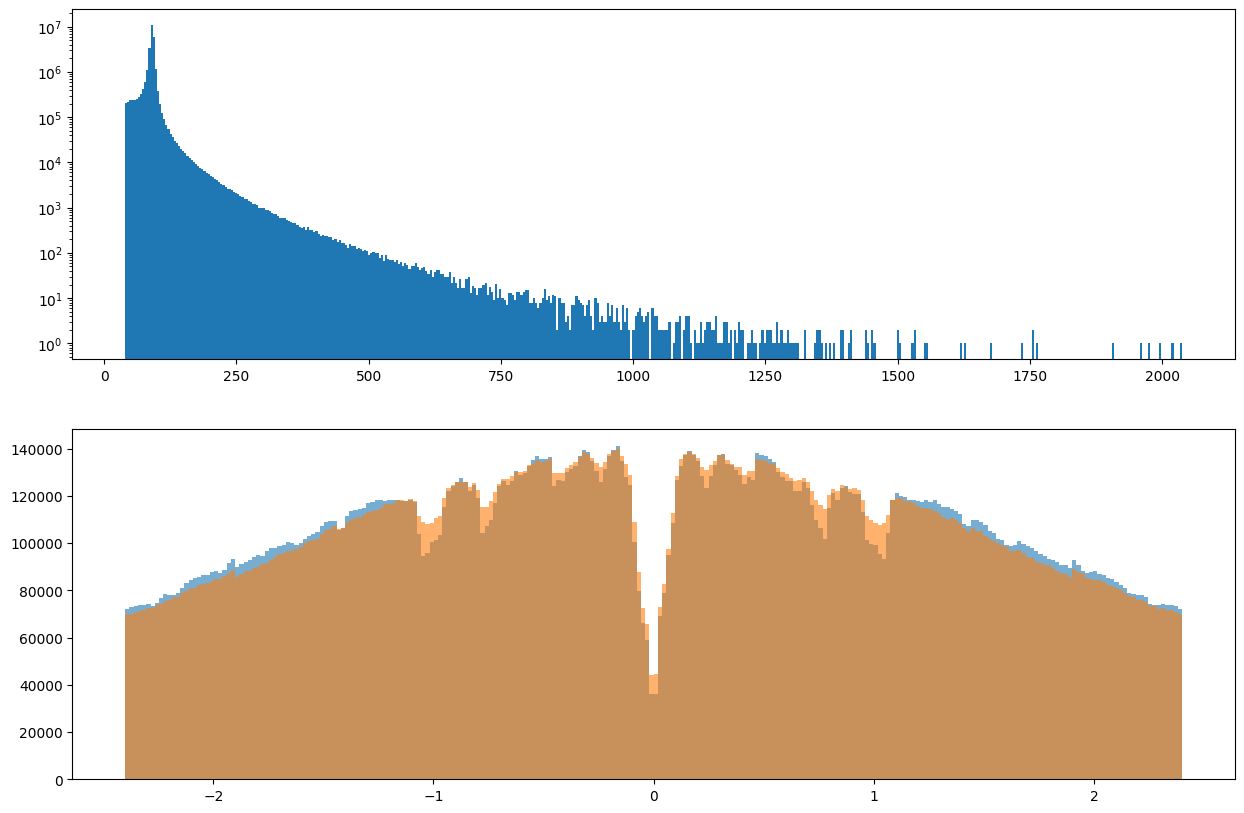

In [16]:
# plot data to make sure it loaded in and cut correctly
mass_hist = huge_data["effective_mass"].hist(bin_count=500)
bin_width_m = (mass_hist["breakpoint"][1:] - mass_hist["breakpoint"][:-1]).mean()

fig = plt.figure(figsize=(15,10))
ax_dict = fig.subplot_mosaic([["mass"], ["pseudorapidity"]])

# centres of the mass bins = mass_hist["breakpoint"] - (bin_width_m / 2)
# plot logarithm of the count to make everything more visible
ax_dict["mass"].bar(mass_hist["breakpoint"] - (bin_width_m / 2), mass_hist["count"], width=bin_width_m)
ax_dict["mass"].set_yscale("log")

pseudorapidity_hist_1 = huge_data["eta_1"].hist(bin_count=250)
bin_width_eta_1 = (pseudorapidity_hist_1["breakpoint"][1:] - pseudorapidity_hist_1["breakpoint"][:-1]).mean()
# centres of the pseudorapidity bins = pseudorapidity_hist_1["eta_1"] - (bin_width_eta_1 / 2)
ax_dict["pseudorapidity"].bar(pseudorapidity_hist_1["breakpoint"] - (bin_width_eta_1 / 2),
                         pseudorapidity_hist_1["count"], width=bin_width_eta_1, alpha=0.6)

pseudorapidity_hist_2 = huge_data["eta_2"].hist(bin_count=250)
bin_width_eta_2 = (pseudorapidity_hist_2["breakpoint"][1:] - pseudorapidity_hist_2["breakpoint"][:-1]).mean()
# centres of the pseudorapidity bins = pseudorapidity_hist_1["eta_1"] - (bin_width_eta_1 / 2)
ax_dict["pseudorapidity"].bar(pseudorapidity_hist_2["breakpoint"] - (bin_width_eta_2 / 2),
                         pseudorapidity_hist_2["count"], width=bin_width_eta_2, alpha=0.6)

plt.show()

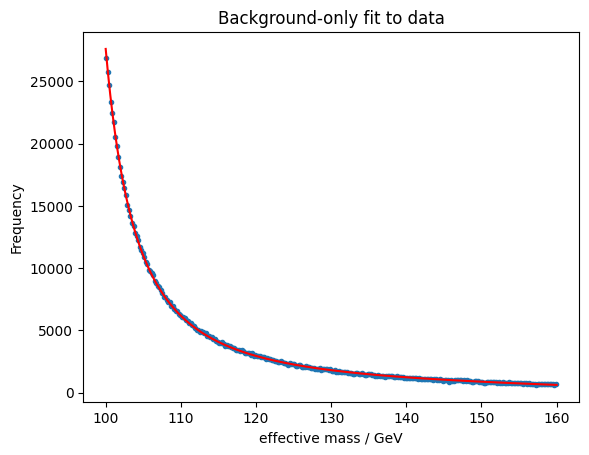

m_Z = 92.59334209869266
Gamma_Z = 0.0005790073357990078
lambda = 0.029169864436565666
beta = 1.2345865957643267
const1 = 225861.51174519263



In [18]:
# try to get initial parameters for background fit

# restrict range
lower_bound = 100
upper_bound = 160

restricted_data = huge_data.remove(
    (pl.col("effective_mass") < lower_bound) | (pl.col("effective_mass") > upper_bound)
)


# sort into bins
fit_hist_data = restricted_data["effective_mass"].hist(bin_count=300)
bin_width = (fit_hist_data["breakpoint"][1:] - fit_hist_data["breakpoint"][:-1]).mean()

# # blind signal region [115, 145]
# fit_hist_data = fit_hist_data.remove(
#     (pl.col("breakpoint") > (110 + bin_width / 2)) & (pl.col("breakpoint") < (140 + bin_width / 2))
# )

bin_centres = np.array(fit_hist_data["breakpoint"] - bin_width / 2)


# fit the curve
popt, pcov = optimize.curve_fit(
    BWplusPhoton, bin_centres, np.array(fit_hist_data["count"]),
    p0=[96.11, -8, 0.01, 1, 10000],
    maxfev=100000000
)

# plot data
plt.scatter(bin_centres, fit_hist_data["count"], marker=".")

# plot fit
masses = np.linspace(lower_bound, upper_bound, 1000)
fit_curve_y = BWplusPhoton(masses, popt[0], popt[1], popt[2], popt[3], popt[4])
plt.plot(masses, fit_curve_y, color="red", label="signal + background")
plt.title("Background-only fit to data")
plt.xlabel("effective mass / GeV")
plt.ylabel("Frequency")
plt.plot()

plt.show()

print(f"m_Z = {popt[0]}\n"
      f"Gamma_Z = {popt[1]}\n"
      f"lambda = {popt[2]}\n"
      f"beta = {popt[3]}\n"
      f"const1 = {popt[4]}\n")

err_m_Z = 0.031257%,
err_Gamma_Z = 7037015.287286%,
err_lambda = 1.588307%,
err_beta = 0.511370%,
err_const1 = 0.109974%,



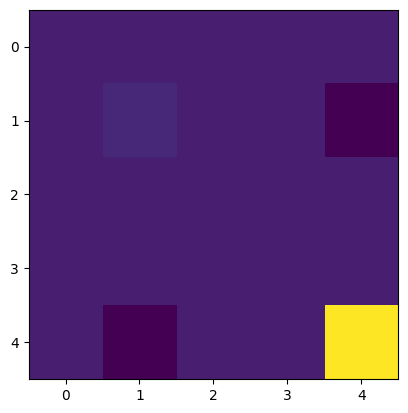

In [19]:
plt.imshow(pcov)
print(f"err_m_Z = {np.sqrt(pcov[0,0]) / popt[0]:%},\n"
      f"err_Gamma_Z = {np.sqrt(pcov[1,1]) / popt[1]:%},\n"
      f"err_lambda = {np.sqrt(pcov[2,2]) / popt[2]:%},\n"
      f"err_beta = {np.sqrt(pcov[3,3]) / popt[3]:%},\n"
      f"err_const1 = {np.sqrt(pcov[4,4]) / popt[4]:%},\n"
      )

C:\Users\karth\AppData\Local\Temp\ipykernel_31412\1011675899.py:30: RuntimeWarning: invalid value encountered in log
  n_l*np.log(n_l/np.abs(alpha_l))  - (alpha_l**2 / 2)
C:\Users\karth\AppData\Local\Temp\ipykernel_31412\1011675899.py:31: RuntimeWarning: invalid value encountered in log
  -n_l*np.log(n_l/np.abs(alpha_l) - np.abs(alpha_l) - (m - m_hat)/sigma)
C:\Users\karth\AppData\Local\Temp\ipykernel_31412\1011675899.py:42: RuntimeWarning: invalid value encountered in log
  n_r*np.log(n_r / np.abs(alpha_r)) - (alpha_r**2/2)
C:\Users\karth\AppData\Local\Temp\ipykernel_31412\1011675899.py:43: RuntimeWarning: invalid value encountered in log
  - n_r*np.log(n_r / np.abs(alpha_r) - np.abs(alpha_r) + (m - m_hat)/sigma)
C:\Users\karth\AppData\Local\Temp\ipykernel_31412\1011675899.py:41: RuntimeWarning: overflow encountered in exp
  high_mass_tail = np.exp(


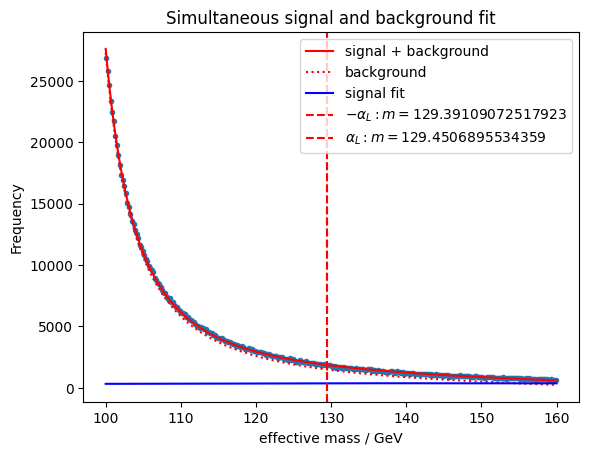

m_Z = 92.53597309617956
Gamma_Z = -0.02782385615594675
lambda = 0.02573491905561281
beta = 1.2913797008766517
const1 = 204206.45344489912

m_hat = 129.46188182229778
sigma = 3.840326721940438
alpha_l = 0.01843361313872591
n_l = 1004209.4665005339
alpha_r = -0.0029144053806517134
n_r = 301402.5975851232
const_2 = 375.71860666110695



In [26]:
# restrict range
lower_bound = 100
upper_bound = 160

restricted_data = huge_data.remove(
    (pl.col("effective_mass") < lower_bound) | (pl.col("effective_mass") > upper_bound)
)

# sort into bins
fit_hist_data = restricted_data["effective_mass"].hist(bin_count=300)
bin_width = (fit_hist_data["breakpoint"][1:] - fit_hist_data["breakpoint"][:-1]).mean()
bin_centres = np.array(fit_hist_data["breakpoint"] - bin_width / 2)

# fit the curve
popt, pcov = optimize.curve_fit(
    signal_and_background, bin_centres, np.array(fit_hist_data["count"]),
    p0=[92, 0.007, 0.03, 1.25, 180000, 130, 3, 2, 1000000, 4, 1000000, 1500],
    maxfev=100000000
)

# plot data
plt.scatter(bin_centres, fit_hist_data["count"], marker=".")

# plot fit
masses = np.linspace(lower_bound, upper_bound, 1000)
fit_curve_y = signal_and_background(masses, popt[0], popt[1], popt[2], popt[3], popt[4],
                                    popt[5], popt[6], popt[7], popt[8], popt[9], popt[10], popt[11],)
background_fit_y = BWplusPhoton(masses, popt[0], popt[1], popt[2], popt[3], popt[4])
signal_fit_y = DSCB(masses, popt[5], popt[6], popt[7], popt[8], popt[9], popt[10], popt[11])
plt.plot(masses, fit_curve_y, color="red", label="signal + background")
plt.plot(masses, background_fit_y, color="red", linestyle=":", label="background")
plt.plot(masses, signal_fit_y, color="blue", label="signal fit")

plt.axvline(-popt[7] * popt[6] + popt[5], label=f"$-\\alpha_L: m = {-popt[7] * popt[6] + popt[5]}$",
            color="red", linestyle="--")
plt.axvline(popt[9] * popt[6] + popt[5], label=f"$\\alpha_L: m = {popt[9] * popt[6] + popt[5]}$",
            color="red", linestyle="--")

plt.title("Simultaneous signal and background fit")
plt.ylabel("Frequency")
plt.xlabel("effective mass / GeV")
plt.legend()
plt.show()

print(f"m_Z = {popt[0]}\n"
      f"Gamma_Z = {popt[1]}\n"
      f"lambda = {popt[2]}\n"
      f"beta = {popt[3]}\n"
      f"const1 = {popt[4]}\n\n"
      f"m_hat = {popt[5]}\n"
      f"sigma = {popt[6]}\n"
      f"alpha_l = {popt[7]}\n"
      f"n_l = {popt[8]}\n"
      f"alpha_r = {popt[9]}\n"
      f"n_r = {popt[10]}\n"
      f"const_2 = {popt[11]}\n")


In [27]:
print(
    f"err_m_Z = {np.sqrt(pcov[0,0]) / popt[0]:%},\n"
    f"err_Gamma_Z = {np.sqrt(pcov[1,1]) / popt[1]:%},\n"
    f"err_lambda = {np.sqrt(pcov[2,2]) / popt[2]:%},\n"
    f"err_beta = {np.sqrt(pcov[3,3]) / popt[3]:%},\n"
    f"err_const1 = {np.sqrt(pcov[4,4]) / popt[4]:%},\n\n"
    f"err_m_hat = {np.sqrt(pcov[5,5]) / popt[5]:%},\n"
    f"err_sigma = {np.sqrt(pcov[6,6]) / popt[6]:%},\n"
    f"err_alpha_L = {np.sqrt(pcov[7,7]) / popt[7]:%},\n"
    f"err_n_L = {np.sqrt(pcov[8,8]) / popt[8]:%},\n"
    f"err_alpha_R = {np.sqrt(pcov[9,9]) / popt[9]:%},\n"
    f"err_n_R = {np.sqrt(pcov[10,10]) / popt[10]:%},\n"
    f"err_const = {np.sqrt(pcov[11,11]) / popt[11]:%},\n"
)

err_m_Z = 0.835926%,
err_Gamma_Z = -1314809.263560%,
err_lambda = 29.317611%,
err_beta = 7.752651%,
err_const1 = 16.226973%,

err_m_hat = 5.668940%,
err_sigma = 19.468722%,
err_alpha_L = 13.219687%,
err_n_L = 13.640531%,
err_alpha_R = -46.146164%,
err_n_R = 51.592564%,
err_const = 152.475767%,

